In [4]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from astro_plot_utils import (
    load_table,
    extract_columns,
    hist_density,
    plot_step_hist
)

In [8]:
PATH_Q1  = "/data/astro/scratch/vdeshpan/data/Q1_general.parquet"
PATH_FS2 = "/data/astro/scratch/vdeshpan/data/FS2_general.parquet"

COLUMN_NAME = "phz_median"

Z_MIN = 0.0
Z_MAX = 3.0
NBINS = 60

In [10]:
df_obs = load_table(PATH_Q1)
df_sim = load_table(PATH_FS2)

z_obs_raw = extract_columns(df_obs, [COLUMN_NAME], dropna=True)[COLUMN_NAME]
z_sim_raw = extract_columns(df_sim, [COLUMN_NAME], dropna=True)[COLUMN_NAME]

print(f"Observed  (Q1): {len(z_obs_raw):,} entries after dropna")
print(f"Simulated     : {len(z_sim_raw):,} entries after dropna")

Observed  (Q1): 29,229,774 entries after dropna
Simulated     : 6,129,558 entries after dropna


In [11]:
mask_obs = (z_obs_raw >= Z_MIN) & (z_obs_raw <= Z_MAX)
mask_sim = (z_sim_raw >= Z_MIN) & (z_sim_raw <= Z_MAX)

z_obs = z_obs_raw[mask_obs]
z_sim = z_sim_raw[mask_sim]

print(f"→ After z ∈ [{Z_MIN}, {Z_MAX}] cut:")
print(f"   Observed : {len(z_obs):,} galaxies")
print(f"   Simulated: {len(z_sim):,} galaxies")

→ After z ∈ [0.0, 3.0] cut:
   Observed : 25,384,492 galaxies
   Simulated: 6,041,626 galaxies


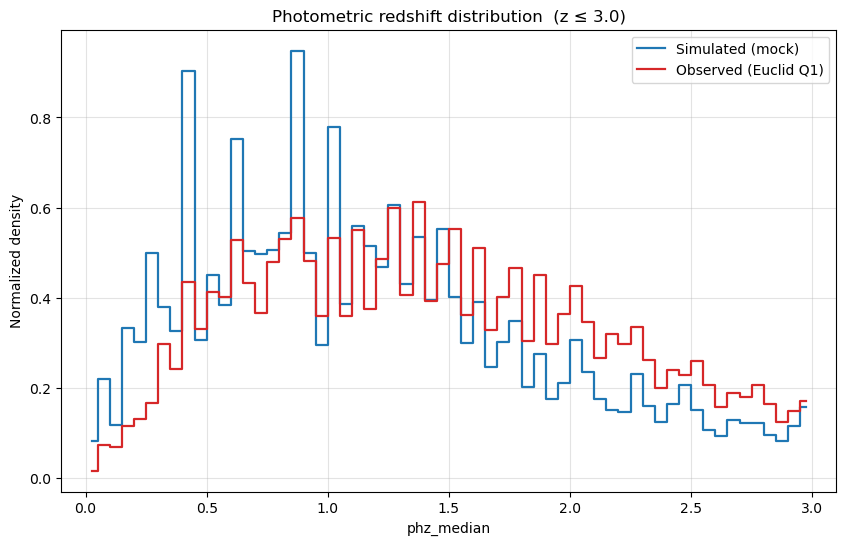

In [12]:
z_bins = np.linspace(Z_MIN, Z_MAX, NBINS + 1)

hist_sim, bin_centers = hist_density(z_sim, bins=z_bins)
hist_obs, _           = hist_density(z_obs, bins=z_bins)

plot_step_hist(
    hists=[
        (hist_sim, bin_centers),
        (hist_obs, bin_centers)
    ],
    labels=[
        "Simulated (mock)",
        "Observed (Euclid Q1)"
    ],
    colors=["#1f77b4", "#d62728"],          # blue + red – classic comparison
    title=f"Photometric redshift distribution  (z ≤ {Z_MAX})",
    xlabel="phz_median",
    ylabel="Normalized density",
    xlim=(Z_MIN - 0.1, Z_MAX + 0.1),
    figsize=(10, 6),
    # save="../plots/redshift_distribution_comparison.png"
)